In [1]:
import pandas as pd
import sys
import os
import importlib
sys.path.append(os.path.abspath('..'))
from scipy.stats import pearsonr
import func
importlib.reload(func)
from func import cal_buoyancy
import metpy.constants as mpconsts
import glob
import os
import re
from metpy.calc import dewpoint_from_specific_humidity, mixed_parcel, specific_humidity_from_dewpoint
import traceback
import datetime
import metpy.calc as mpcalc
from metpy.units import units
from metpy.cbook import get_test_data
from metpy.plots import add_metpy_logo, SkewT
from scipy.interpolate import interp1d
from scipy.optimize import bisect
import numpy as np
import pickle
import numpy as np
import math
import pint
from pydoc import help
import xarray as xr
import netCDF4 as nc
import re
import matplotlib.pyplot as plt
from numpy import load
from numpy import asarray
from numpy import save
import pytz
from scipy import stats
from sklearn.linear_model import LinearRegression
from collections import Counter
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import pymannkendall as mk
%matplotlib inline

In [2]:
# Set display options to show all rows and columns in dataframe

pd.set_option('display.max_rows', None)

pd.set_option('display.max_columns', None)

np.set_printoptions(threshold=np.inf)

In [3]:
directory_path = "/data/rong1/climate_fu/Data/DOEARM/sgp/sondewnpn"

files = [
    
    os.path.join(directory_path, file)
    
    for file in os.listdir(directory_path)
    
    if file.endswith(".cdf")
]

filtered_files = []

for file in files:
    
    file_name = os.path.basename(file)
    
    year_month = file_name.split('.')[2]
    
    if len(year_month) == 8:
        
        year = int(year_month[0:4])
        
        month = int(year_month[4:6])
        
        day = int(year_month[6:8])
        
        hours_mins_seconds = file_name.split('.')[3]
        
        hour = int(hours_mins_seconds[0:2])
        
        if 5 <= month <= 9 and 2020 > year > 2000 and hour == 17:
            
            filtered_files.append(file)


dfs = []

for ds in sorted(filtered_files):
    
    ds = xr.open_dataset(ds)
    
    dfs.append(ds)

In [4]:
def count_nans(arr):
    
    return np.isnan(arr).sum()

def count_non_nan(arr):
    
    return arr.shape[0]

def get_max_alt(arr):
    
    return arr.max()

In [5]:
def time_adjustment(file):
    
    bt = pd.to_datetime(file.variables["base_time"].data)
    
    t = file.coords["time"].data[0]
    
    t_off = file.variables["time_offset"].data[0]
    
    bt = pd.Timestamp(bt)
    
    t_off = pd.Timestamp(t_off)
    
    yr = bt.year
    
    month = bt.month
    
    day = bt.day
    
    if bt.hour == 0 and bt.minute == 0 and bt.second == 0:
        
        hr = t_off.hour
        
        minute = t_off.minute
        
        second = t_off.second
    
    else:
        
        hr = bt.hour
        
        minute = bt.minute
        
        second = bt.second
    
    time_final = (yr, month, day, hr, minute, second)
    
    time_final = datetime.datetime(*time_final)
    
    return(time_final)

In [6]:
#clean relevant variables: pressure, dewpoint, height

df_fill_nans = []

for df in dfs:
    
    time = time_adjustment(df)
    
    #clean relative humidity
    rh = df.variables['rh'].data
    
    rh_lower_bound = 0
    
    rh_upper_bound = 100
    
    mask = (rh < rh_lower_bound) | (rh > rh_upper_bound)
    
    rh_clean = np.where(mask, np.nan, rh)
    
    #clean pressure
    pres = df.variables['pres'].data
    
    pres_lower_bound = 0
    pres_upper_bound = 1100

    mask = (pres < pres_lower_bound) | (pres > pres_upper_bound)

    pres_clean = np.where(mask, np.nan, pres)
    
#     is_decreasing = np.all(np.diff(pres_clean) < 0)
    
#     if is_decreasing == True:
#         pres_clean = pres_clean
#     else:
#         print('non decreasing pressure')
    
    #clean altitude
    
    alt = df.variables['alt'].data
    
    alt_lower_bound = 313
    
    alt_upper_bound = 30000
    
    mask = (alt < alt_lower_bound) | (alt > alt_upper_bound)

    alt_clean = np.where(mask, np.nan, alt)
    
    #clean dewpoint
    dp = df.variables['dp'].data

    dp_lower_bound = -110
    
    dp_upper_bound = 50
    
    mask = (dp < dp_lower_bound) | (dp > dp_upper_bound)

    dp_clean = np.where(mask, np.nan, dp)
    
    #clean temperature
    
    tdry = df.variables['tdry'].data
    
    tdry_lower_bound = -200
    
    tdry_upper_bound = 200
    
    mask = (tdry < tdry_lower_bound) | (tdry > tdry_upper_bound)
    
    tdry_clean = np.where(mask, np.nan, tdry)
    
    cleaned_arrays=(time, pres_clean, alt_clean, dp_clean, rh_clean, tdry_clean)
    
    df_fill_nans.append(cleaned_arrays)
    
df_fill_nans = pd.DataFrame(df_fill_nans, columns=['time','pres','alt','dp','rh','tdry'])

df_fill_nans = df_fill_nans.set_index('time')

#dropping duplicates along index

df_fill_nans = df_fill_nans[~df_fill_nans.index.duplicated(keep='first')]

df_fill_nans.shape

(2720, 5)

In [7]:
print(df_fill_nans.shape)

height_threshold = 15000

mask = df_fill_nans['alt'].apply(get_max_alt) >= height_threshold

df = df_fill_nans[mask]

print("final df: ",df.shape)

(2720, 5)
final df:  (2626, 5)


In [8]:
max_alt = 15000

def interpolate_rh(df,rh_name,alt_name):
    
    interpolated_rh =[]
    
    for index, row in df.iterrows():
        
        x = row[alt_name]
        
        y = row[rh_name]
        
        f = interp1d(x, y, assume_sorted = False)
        
        max_x = max_alt
        
        min_x = np.ceil(np.nanmin(x))
        
        xnew = np.arange(min_x, max_x, 20)
        
        ynew = f(xnew)
        
        interpolated_rh.append(ynew)
    
    df['interp_rh'] = interpolated_rh


def interpolate_alt(df,alt_name):
    
    interpolated_alts = []
    
    for index, row in df.iterrows():
        
        x = row[alt_name]
        
        max_x = max_alt
        
        min_x = np.ceil(np.nanmin(x))
        
        xnew = np.arange(min_x, max_x, 20)
        
        #shifting altitudes to start at 0 according to AGL
        
        xnew = xnew-315
        
        interpolated_alts.append(xnew)
    
    df['interp_alt'] = interpolated_alts

    return df


def interpolate_dewpoint(df,dp_name,alt_name):
    
    interpolated_dp = []
    
    for index, row in df.iterrows():
        
        x = row[alt_name]
        
        y = row[dp_name]
        
        f = interp1d(x, y, assume_sorted = False)
        
        max_x = max_alt
        
        min_x = np.ceil(np.nanmin(x))
        
        xnew = np.arange(min_x, max_x, 20)
        
        ynew = f(xnew)*units.degC
        
        ynew = ynew.magnitude
        
        interpolated_dp.append(ynew)
    
    df['interp_dp'] = interpolated_dp
    
def interpolate_temp(df,temp_name,alt_name):
    
    interpolated_temps = []
    
    for index, row in df.iterrows():
        x = row[alt_name]
        
        y = row[temp_name]
        
        f = interp1d(x, y, assume_sorted = False)
        
        max_x = max_alt
        
        min_x = np.ceil(np.nanmin(x))
        
        xnew = np.arange(min_x, max_x, 20)
        
        ynew = f(xnew)*units.degC
        
        ynew = ynew.magnitude
        
        interpolated_temps.append(ynew)
    
    df['interp_temp'] = interpolated_temps

def interpolate_pressure(df,pres_name,alt_name):
    
    interpolated_pres = []
    
    for index, row in df.iterrows():
        
        x = row[alt_name]
        
        y = row[pres_name]
        
        f = interp1d(x, y, assume_sorted = False)
        
        max_x = max_alt
        
        min_x = np.ceil(np.nanmin(x))
        
        xnew = np.arange(min_x, max_x, 20)
        
        ynew = f(xnew)*units.hPa
        
        ynew = ynew.magnitude
        
        interpolated_pres.append(ynew)
    
    df['interp_pres'] = interpolated_pres

In [9]:
interpolate_alt(df=df,alt_name='alt')

interpolate_temp(df=df,temp_name='tdry',alt_name='alt')

interpolate_dewpoint(df=df,dp_name='dp',alt_name='alt')

interpolate_pressure(df=df,pres_name='pres',alt_name='alt')

interpolate_rh(df=df,rh_name='rh',alt_name='alt')

df.index = df.index.date

/tmp/ipykernel_12071/173537997.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['interp_alt'] = interpolated_alts
/home/annierosen16/anaconda3/envs/annieenv/lib/python3.9/site-packages/scipy/interpolate/_interpolate.py:698: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/annierosen16/anaconda3/envs/annieenv/lib/python3.9/site-packages/scipy/interpolate/_interpolate.py:698: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/annierosen16/anaconda3/envs/annieenv/lib/python3.9/site-packages/scipy/interpolate/_interpolate.py:701: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/

In [10]:
def q_calc(row):
    
    pres = row['interp_pres']*units.hPa
    
    dp = row['interp_dp']*units.degC
    
    q_list=[]
    
    length = pres.shape[0]

    for i in range(length):
        
        q = mpcalc.specific_humidity_from_dewpoint(pres[i],dp[i]).to('g/kg')
        
        q_list.append(q.magnitude)

    return q_list

df['q_obs'] = df.apply(q_calc, axis=1)

/tmp/ipykernel_12071/1242873496.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['q_obs'] = df.apply(q_calc, axis=1)


In [11]:
# #to pass to ctp/hilow --> fig 2&3 reconstruction

# with open('soundings_fig1&4.pkl', 'wb') as file:
    
#     pickle.dump(df, file)

In [12]:
dfsafe = df.copy()

In [63]:
# df = dfsafe.copy()

In [13]:
# Apply the function to the specified column and create a mask for rows with <= 10 NaN values

max_nans = 0

mask = df['pres'].apply(count_nans) <= max_nans

df = df[mask]

mask = df['alt'].apply(count_nans) <= max_nans

df = df[mask]

mask = df['dp'].apply(count_nans) <= max_nans

df = df[mask]

mask = df['tdry'].apply(count_nans) <= max_nans

df = df[mask]

min_elems = 2500

mask = df['pres'].apply(count_non_nan) >= min_elems

df = df[mask]

print(df.shape)

#(2437,11)

(2437, 11)


In [14]:
#daily q_fit calculation, adds a column called q_fit to df

q_corr_df = df['q_obs'].apply(pd.Series)

# q_corr_df = q_corr_df.dropna()

new_cols = range(0, len(q_corr_df.columns) * 20, 20)

q_corr_df.columns = new_cols

bottom_1km = 51

near_surface_layer = q_corr_df.iloc[:, :bottom_1km].mean(axis=1)

lr = LinearRegression()

X_input = near_surface_layer.values

X_input = X_input.reshape(len(near_surface_layer),1)

#q_fit is the same as observed q in the bottom 2km

bottom_2km = 101

q_fit = q_corr_df.iloc[:, :bottom_2km].copy()

stats_list=[]

for i in q_corr_df.columns:
    
    if 4000 >= i > 2000:
        
        y_target = q_corr_df.loc[:,i].values
        
        y_target = y_target.reshape(len(y_target),1)
        
        model = lr.fit(X_input,y_target)
        
        y_model = model.predict(X_input)
        
        model_mean = np.mean(y_model)
        
        model_std = np.std(y_model)
        
        obs_mean = np.mean(y_target)
        
        obs_std = np.std(y_target)
        
        stats = (i, model_mean, obs_mean, model_std, obs_std) 
        
        stats_list.append(stats)
        
        q_fit['{}_fit'.format(i)] = y_model

df['q_fit']=""

for i in range(df.shape[0]):
    
    q_fit_i = q_fit.iloc[i,:]
    
    df['q_fit'][i] = q_fit_i
    
model_v_obs_df = pd.DataFrame(stats_list,columns=['height','model_mean','obs_mean','model_std','obs_std']) 

/tmp/ipykernel_12071/470100642.py:53: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  q_fit['{}_fit'.format(i)] = y_model


In [67]:
df['q_obs'].iloc[0][0:201]

735

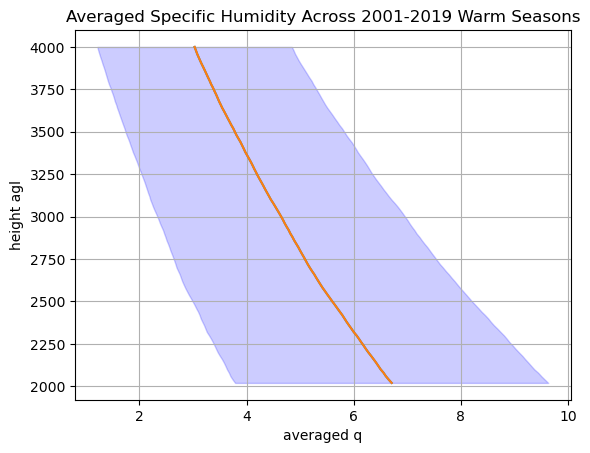

In [15]:
model_v_obs_df['std_plus'] = model_v_obs_df['obs_mean']+model_v_obs_df['obs_std']

model_v_obs_df['std_mins'] = model_v_obs_df['obs_mean']-model_v_obs_df['obs_std']

mm = model_v_obs_df['model_mean']

obm = model_v_obs_df['obs_mean']

mstd = model_v_obs_df['model_std']

obstd = model_v_obs_df['obs_std']

h = model_v_obs_df['height']

fillp = model_v_obs_df['std_plus']

fillm = model_v_obs_df['std_mins']

plt.plot(obm,h)

plt.plot(mm,h)

plt.fill_betweenx(h,fillm,fillp,alpha=0.2,color='blue')

plt.xlabel('averaged q')

plt.ylabel('height agl')

plt.title('Averaged Specific Humidity Across 2001-2019 Warm Seasons')

plt.grid(True)

plt.show()

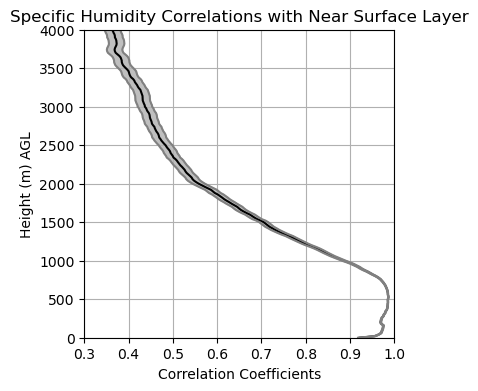

In [16]:
correlations = q_corr_df.corrwith(near_surface_layer)

column_names = correlations.index

ses = []

sqrt_num_rows = np.sqrt(df.shape[0])

for i in correlations.index:
    
    se = (1 - (correlations[i]**2))/sqrt_num_rows
    
    ses.append(se)

plt.figure(figsize=(4, 4))

plt.plot(correlations, column_names, color='black')

plt.plot(correlations + ses, column_names, color='grey')

plt.plot(correlations - ses, column_names, color='grey')

plt.fill_betweenx(column_names, correlations - ses, correlations + ses, color='grey', alpha=0.5, label='Error Bars')

plt.xlabel('Correlation Coefficients')

plt.ylabel('Height (m) AGL')

plt.ylim(0,4000)

plt.xticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0])

plt.xlim(0.3,1.0)

plt.title('Specific Humidity Correlations with Near Surface Layer')

plt.grid(True)

plt.show()

### previous method to calculate buoyancy, using temperature of parcel and temperature of environment 

In [16]:
# # %run /home/annierosen16/func.ipynb

# df["blt"]=""

# df["blc"]=""

# df["br"]=""

# errors=0

# for index in range(df.shape[0]):
    
#     try: 

#         row = df.iloc[index,:]

#         alt = row['interp_alt'][0:201]

#         p = row['interp_pres'][0:201]

#         t = row['interp_temp'][0:201]

#         dp = row['interp_dp'][0:201]

#         qlc = np.array(row['q_fit'])

#         qr = np.array(row['q_obs'][0:201])

#         b_qr = cal_buoyancy(t_profile = t,         
#                                 h_profile = qr,         
#                                 p_profile = p,        
#                                 alt_profile = alt,
#                                 entrain_opt = 2
#                                 )

#         b_qlc = cal_buoyancy(t_profile = t,         
#                             h_profile = qlc,         
#                             p_profile = p,        
#                             alt_profile = alt,
#                             entrain_opt = 2 
#                             )
        
#         pprof_qr = (b_qr.tp)*units.degK

#         pprof_qlc = (b_qlc.tp)*units.degK
        
#         #i believe problem in final blt calculation is in here somewhere, related to units when i integrate

#         t = row['interp_temp'][0:201]*units.degC

#         t = t.to(units.degK)

#         y_qr = pprof_qr - t

#         y_qlc = pprof_qlc - t
        
#         pres_100 = p[0]-100

#         pres_300 = p[0]-300

#         pres_mask = (p >= pres_300) & (p <= pres_100)

#         altmask = (alt >= 2000) & (alt <= 4000)
        
# #         x_clipped = p[pres_mask]

# #         y_clipped_qr = y_qr[pres_mask]

# #         y_clipped_qlc = y_qlc[pres_mask]

#         x_clipped = p[altmask]

#         y_clipped_qr = y_qr[altmask]

#         y_clipped_qlc = y_qlc[altmask]
        
#         #multiply by kelvin here? check units

#         buoyancy_r = (mpconsts.Rd*(np.trapz(y_clipped_qr[::-1], np.log(x_clipped[::-1])))).to(units('J/kg'))

#         buoyancy_lc = (mpconsts.Rd*(np.trapz(y_clipped_qlc[::-1], np.log(x_clipped[::-1])))).to(units('J/kg'))

#         blt = buoyancy_r - buoyancy_lc

#         df["blt"][index] = blt.magnitude

#         df["blc"][index] = buoyancy_lc.magnitude
        
#         df["br"][index] = buoyancy_r.magnitude

#         print(index, blt.magnitude, buoyancy_lc.magnitude, buoyancy_r.magnitude)
    
#     except Exception as e:
        
#         errors+=1
        
#         print(e)
    

0 6.333258159022989 -175.0402909908195 -168.7070328317965
1 -5.758824827651722 -309.8677878304393 -315.626612658091
2 7.431794053810762 -197.9813997096956 -190.54960565588485
3 3.863177905857981 -107.39074981063419 -103.52757190477621
4 2.6012779089376608 -112.1637710838369 -109.56249317489925
5 -10.549165566825678 -196.6832315884023 -207.23239715522797
6 13.621559658695176 -86.80139692114521 -73.17983726245004
7 13.08789897458891 -92.2744298198736 -79.1865308452847
8 13.035435544172003 -233.15598830648702 -220.12055276231501
9 -6.5225781834631675 -257.0500851454939 -263.57266332895705
10 2.611599929464319 -175.8610268901896 -173.2494269607253
11 0.8850085135920267 -129.14596778432457 -128.26095927073254
12 -0.0709450964893108 -147.9210954880733 -147.9920405845626
13 -0.3083191274074011 -89.87646208262952 -90.18478121003692
14 -8.801308749078117 -160.5884624109211 -169.3897711599992
15 3.172683063452382 -321.3018807210806 -318.1291976576282
16 5.070986281055667 -189.21044541579704 -184

135 8.475943596938862 -167.37643145233403 -158.90048785539517
136 4.904092347179315 -37.62126490887649 -32.717172561697176
137 7.779788498197547 -186.16429111180054 -178.384502613603
138 -4.279271277518774 -158.74094613830084 -163.02021741581962
139 -3.1220731303612013 -176.51410196420412 -179.63617509456532
140 3.731401865993263 -128.60502911891882 -124.87362725292556
141 7.815354377013875 -126.23944022275764 -118.42408584574376
142 -3.71140799858307 -218.5978734934133 -222.30928149199636
143 3.172100571428075 -271.2188971132247 -268.04679654179665
144 20.93139542127659 -174.01594322694504 -153.08454780566845
145 0.6032285991468598 -71.09048510674025 -70.48725650759339
146 22.785067088135065 -284.62880948021865 -261.8437423920836
147 -10.896083229440933 -549.292828754943 -560.1889119843839
148 4.769902972539384 -102.14977988885913 -97.37987691631974
149 -4.6858415107332405 -197.65537222849034 -202.34121373922358
150 -6.8843690219569 -340.8812122763563 -347.7655812983132
151 -8.8527379

268 -2.246164608055949 -220.84593041122992 -223.09209501928586
269 7.395975625230051 -283.90322521063223 -276.5072495854022
270 11.79154009434825 -386.046276524853 -374.25473643050475
271 -8.137426528387778 -289.4533791260277 -297.5908056544155
272 11.481392994733085 -76.45837252043775 -64.97697952570466
273 -1.4412796376622623 -148.93045357898978 -150.37173321665205
274 5.016053467185159 -130.5448719254696 -125.52881845828445
275 6.542453058642138 -161.24620065804672 -154.70374759940458
276 0.7812524961874487 -304.2634373697028 -303.48218487351534
277 4.099055025603775 -234.695825500695 -230.59677047509123
278 0.4967178038198483 -192.00506412349836 -191.5083463196785
279 8.765019319627385 -165.2297572129141 -156.46473789328672
280 -4.078918667159286 -228.79660187127334 -232.87552053843262
281 10.132927933965576 -125.64114333373567 -115.5082153997701
282 10.2443815681141 -60.55575125309866 -50.31136968498456
283 5.3059182320860145 -151.3118704683562 -146.0059522362702
284 9.14747959266

401 -3.4592545509011643 -201.8344363346911 -205.29369088559227
402 -19.01556432479532 -201.50075154868946 -220.51631587348479
403 12.105916102823045 -222.95970822103013 -210.85379211820708
404 8.678188391661166 -167.0677388950122 -158.38955050335105
405 7.6640534586907165 -107.01554166578738 -99.35148820709666
406 17.28015579988687 -416.67613835603464 -399.39598255614777
407 2.414274557392332 -409.7905758195872 -407.3763012621949
408 -2.4643545025328137 -255.81258212709187 -258.2769366296247
409 0.3546097260513079 -185.02375028638895 -184.66914056033764
410 -10.959094841244422 -189.8529764110176 -200.81207125226203
411 8.037543679134188 -165.42110816576383 -157.38356448662964
412 -6.382837759263708 -186.41153103609048 -192.7943687953542
413 6.108766512455929 -201.74240101533647 -195.63363450288054
414 4.596778524094248 -286.93528200512856 -282.3385034810343
415 -9.598954790277844 -272.7104230668687 -282.30937785714656
416 -3.1271211970150716 -252.51792073973482 -255.6450419367499
417 -

535 3.719159200891596 -148.62679192595618 -144.9076327250646
536 9.603188118306683 -41.9632594705733 -32.360071352266615
537 8.71175629587404 -170.84227188994015 -162.1305155940661
538 3.0807675778789587 -132.1564357522754 -129.07566817439644
539 0.4415052756219211 -238.8675865869103 -238.42608131128839
540 -0.2646222746949718 -237.9007030313768 -238.16532530607176
541 0.6437242383051966 -386.7083726368635 -386.0646483985583
542 11.662489174936752 -85.24103679116905 -73.5785476162323
543 12.45666062231804 -128.5494691502214 -116.09280852790336
544 16.345040031594493 -235.55951280966804 -219.21447277807354
545 10.07119269480512 -319.95884570784995 -309.8876530130448
546 13.250079522810381 -244.70325006487082 -231.45317054206043
547 7.1258010778250025 -118.16436917091491 -111.0385680930899
548 10.298253812654906 -139.05361855102333 -128.75536473836843
549 1.2439356113270605 -216.29282305017597 -215.0488874388489
550 16.67080657521967 -17.222611227490116 -0.5518046522704432
551 24.7822840

...

1852 -9.702249944545997 -240.07638045776082 -249.77863040230682
1853 41.40913686163742 -682.6907200992654 -641.281583237628
1854 28.34585785930244 -609.7317640206571 -581.3859061613547
1855 22.564739186982933 -468.9387728948354 -446.37403370785245
1856 -11.780068543746921 -179.35908628208094 -191.13915482582786
1857 -4.263306806306673 -303.7771598636048 -308.0404666699115
1858 17.13514266980559 -285.9777007349019 -268.8425580650963
1859 -3.79434187840684 -460.4333899544274 -464.22773183283425
1860 -3.5297556215412556 -216.95347999280102 -220.48323561434228
1861 6.77031657507186 -243.27667096904196 -236.5063543939701
1862 -0.12180390346730974 -247.81839069048598 -247.9401945939533
1863 -5.944088336759734 -252.60339526019575 -258.5474835969555
1864 6.826327434754646 -106.32138174665828 -99.49505431190363
1865 8.97416398202887 -181.78952541407116 -172.8153614320423
1866 15.454817746036383 -131.350580399357 -115.89576265332062
1867 -20.90749712654778 -173.55728457194834 -194.46478169849613

1983 -16.500779115641194 -379.7987584434841 -396.29953755912527
1984 9.739775167916832 -299.2508180814799 -289.5110429135631
1985 12.94540920479244 -171.98110174496617 -159.03569254017373
1986 11.043538949420252 -250.62643985444768 -239.58290090502743
1987 6.784440513773745 -165.45691903578103 -158.67247852200728
1988 21.602394370603662 -207.43023746017712 -185.82784308957346
1989 2.4046201599493315 -217.49359434680025 -215.08897418685092
1990 -11.909903850507419 -270.63541264577736 -282.5453164962848
1991 -15.122348644663617 -209.18589248203713 -224.30824112670075
1992 2.5099356717131514 -219.95718365553446 -217.4472479838213
1993 -14.711819652473594 -186.83791966491953 -201.54973931739312
1994 -12.04298674890481 -194.14927083868395 -206.19225758758876
1995 -12.174129549271129 -300.5329591393076 -312.7070886885787
1996 -9.047310898186709 -226.96793810963885 -236.01524900782556
1997 15.583427958380936 -12.719073508907059 2.864354449473877
1998 16.64840671251227 -392.87228736635865 -376

2114 -9.329278293692084 -233.99497426646602 -243.3242525601581
2115 16.090789952587215 -155.798767263792 -139.7079773112048
2116 -6.601754725218143 -261.3698461313152 -267.97160085653337
2117 -15.554950391541468 -292.08624890794755 -307.641199299489
2118 -17.570433273775393 -518.4163127087273 -535.9867459825027
2119 -11.8675519240183 -486.62583590917245 -498.49338783319075
2120 -14.68726244909908 -402.04275432191156 -416.73001677101064
2121 -12.322376013154098 -405.51788319850345 -417.84025921165755
2122 10.76976568177497 -170.38916351579584 -159.61939783402087
2123 -5.207049467688876 -309.5575488709263 -314.7645983386152
2124 -1.8544401924756357 -299.1396279596341 -300.9940681521097
2125 14.746421599610244 -454.03306765824743 -439.2866460586372
2126 -7.079614585933598 -360.8040771544757 -367.8836917404093
2127 6.915615739559826 -392.08642696633126 -385.17081122677143
2128 14.749188058074253 -373.6274341746344 -358.87824611656015
2129 3.757144935212409 -404.9096372140276 -401.152492278

2245 17.379246726199625 -188.81203057481824 -171.4327838486186
2246 5.264386790575429 -337.5839513542145 -332.31956456363906
2247 -4.019862137833854 -63.17390368969342 -67.19376582752727
2248 6.003158830479251 -28.901230876269718 -22.898072045790467
2249 -2.683815494773455 -86.58648425823951 -89.27029975301296
2250 17.77573903812369 -115.90238310483277 -98.12664406670908
2251 21.70482235763481 -140.02565971933316 -118.32083736169835
2252 12.560918966561303 -90.28828431868138 -77.72736535212007
2253 -12.40067352147571 -417.154902192467 -429.5555757139427
2254 15.436891604369379 -109.58460098146837 -94.14770937709899
2255 5.622022360008174 -241.9394064977339 -236.31738413772572
2256 1.2688644755214682 -342.17297508719196 -340.9041106116705
2257 7.822510448753661 -199.37735161537768 -191.55484116662402
2258 7.765812001592224 -320.0418545148201 -312.2760425132279
2259 -24.530123601827427 -480.93882671623714 -505.46895031806457
2260 15.131766547940884 -217.33308391857935 -202.20131737063846

2376 -15.632236899115014 -409.2505885453367 -424.8828254444517
2377 -9.975447442116092 -452.86844574966074 -462.84389319177683
2378 -15.388787881100939 -448.4640802185298 -463.8528680996307
2379 -1.26315010666994 -205.2892027082024 -206.55235281487234
2380 -19.09423933376226 -239.67573219122718 -258.76997152498944
2381 3.245601977191427 -231.88429443681127 -228.63869245961985
2382 -7.158122009372335 -203.38759432307344 -210.54571633244578
2383 8.042002799648742 -273.83829075557094 -265.7962879559222
2384 13.530558232425506 -215.6502516142938 -202.1196933818683
2385 27.201664426179235 -218.76845051693311 -191.56678609075388
2386 8.63128779496364 -136.3213058327519 -127.69001803778826
2387 -11.046139599940943 -156.22354864692477 -167.2696882468657
2388 7.929477009911523 -78.32771740551773 -70.39824039560621
2389 23.273325157670143 -59.432320641438835 -36.15899548376869
2390 18.349854762267427 -271.1513755464187 -252.80152078415128
2391 9.00544045697211 -274.1238829906029 -265.11844253363

In [17]:
g = 9.81 # m/s2

df["blt_bug"] = ""

df["blc_bug"] = ""

df["br_bug"] = ""

errors=0

for index in range(df.shape[0]):
    
    try: 

        row = df.iloc[index,:]
        
        # 0 -> 4km above ground level 

        alt = row['interp_alt'][0:201]

        p = row['interp_pres'][0:201]

        t = row['interp_temp'][0:201]

        dp = row['interp_dp'][0:201]

        qfit = np.array(row['q_fit'])

        q = np.array(row['q_obs'][0:201])

        # create a mixed parcel 

        p_hpa = p * units.hPa

        alt_m = alt * units.meter

        t_degC = t * units.degC

        dewpt_degC = dp * units.degC

        dewpt_degC_qfit = dewpoint_from_specific_humidity(p_hpa, qfit * units('g/kg'))

        mp_pres, mp_temp, mp_dewpt = mixed_parcel(p_hpa, t_degC, dewpt_degC, depth=1000*units.meter, height=alt_m)

        # update arrays with mixed parcel temperature and humidity 

        t_mix = t.copy()

        t_mix[0] = mp_temp.magnitude

        t_mix = t_mix + 273.15

        # updating dp

        dp_mix = dewpt_degC.magnitude

        dp_mix_fit = dewpt_degC_qfit.magnitude

        dp_mix[0] = mp_dewpt.magnitude

        dp_mix_fit[0] = mp_dewpt.magnitude

        # temperature = Kelvin, q = g/kg

        # buoyancy given environmental t, q, and p with first element replaced with mixed parcel value

        br = cal_buoyancy(t_profile=t_mix, h_profile=dp_mix, p_profile=p, alt_profile=alt, entrain_opt=2, td_r_q=1)

        # br = cal_buoyancy(t_profile=t, h_profile=q, p_profile=p, alt_profile=alt, entrain_opt=2)

        # # buoyancy given environmental t, qfit, and p with first element replaced with mixed parcel value

        blc = cal_buoyancy(t_profile=t_mix, h_profile=dp_mix_fit, p_profile=p, alt_profile=alt, entrain_opt=2, td_r_q=1)

        pprof_qr = (br.tp)*units.degK

        pprof_qlc = (blc.tp)*units.degK
        
        t_mix = t_mix * units.kelvin
        
        y_qr = pprof_qr - t_mix

        y_qlc = pprof_qlc - t_mix

        altmask = (alt >= 2000) & (alt <= 4000)

        x_clipped = p[altmask]

        y_clipped_qr = y_qr[altmask]

        y_clipped_qlc = y_qlc[altmask]
        
        #multiply by kelvin here? check units

        buoyancy_r = (mpconsts.Rd*(np.trapz(y_clipped_qr[::-1], np.log(x_clipped[::-1])))).to(units('J/kg'))

        buoyancy_lc = (mpconsts.Rd*(np.trapz(y_clipped_qlc[::-1], np.log(x_clipped[::-1])))).to(units('J/kg'))

        blt = buoyancy_r - buoyancy_lc

        df["blt_bug"][index] = blt.magnitude

        df["blc_bug"][index] = buoyancy_lc.magnitude
        
        df["br_bug"][index] = buoyancy_r.magnitude
                
        print(blt.magnitude, buoyancy_lc.magnitude, buoyancy_r.magnitude) 
    
    except Exception as e:
        
        errors+=1
        
        print(e)
    

12.880490783932373 -111.19617101062478 -98.31568022669241
-13.177074935404164 -295.2093276518762 -308.3864025872804
15.238136425100862 -175.21723371606066 -159.9790972909598
8.220484395633868 -62.00478407654986 -53.78429968091599
5.410619629218559 -73.43302992010233 -68.02241029088377
-25.028316991133778 -165.6340455423469 -190.6623625334807
23.191259771481104 7.140034188662676 30.33129396014378
25.719617499218543 -79.49075844521809 -53.77114094599955
20.199648431314372 -107.25616405954844 -87.05651562823407
-11.562168102407867 -131.92562891616012 -143.487797018568
4.878482562033682 -117.07589717464215 -112.19741461260847
1.9741325032556887 -92.20969822649415 -90.23556572323847
-0.6403040604235457 -131.53753529192878 -132.17783935235232
-0.9264604368017331 39.06814614964329 38.14168571284156
-17.158017944675095 -90.05400257230951 -107.21202051698461
5.966398117175572 -322.47310189981454 -316.50670378263897
8.37712465951222 -212.81471924547512 -204.4375945859629
-22.226177267606204 -134

34.47967514727628 -98.8985528963728 -64.41887774909652
0.9191567801052258 48.96901189889755 49.888168679002774
39.12161828550822 -287.6537552733076 -248.53213698779936
-24.14703556672532 -581.9057732538707 -606.052808820596
6.576306083846916 36.580879636571844 43.15718572041876
-8.096590490392202 -52.098211834700685 -60.19480232509289
-14.951243949935957 -237.28292604596302 -252.23416999589898
-15.19863353660702 -59.34668145382504 -74.54531499043206
-13.419091488270695 -123.99199157556406 -137.41108306383475
12.875992710222746 -134.35201868256112 -121.47602597233838
26.686823288579646 -125.4380538560859 -98.75123056750625
13.036754065955336 -47.75813183829759 -34.72137777234225
23.260326760262842 -173.44689825879829 -150.18657149853544
-9.254700711292003 -176.98670729220723 -186.24140800349923
-8.344412978856155 -320.53579667302813 -328.8802096518843
-0.006924907889754195 -246.5507407450932 -246.55766565298296
-9.063562662968025 -124.39411395242902 -133.45767661539705
-1.29899136946454

11.685603071698523 -48.74867987676586 -37.06307680506734
21.427806024591206 -177.75828525685876 -156.33047923226755
2.3100802091657897 -392.27027206553703 -389.96019185637124
-1.920901573714616 -451.5770753182079 -453.4979768919225
-28.568529124087263 -262.3475627186129 -290.91609184270015
14.418866388716992 -287.38962357402596 -272.97075718530897
7.257050829852972 -344.2296189355798 -336.97256810572685
-13.754375005088605 -276.55118196273503 -290.30555696782363
-21.44470942349801 -503.80619738306984 -525.2509068065679
-19.21099729445737 -241.60024615291556 -260.81124344737293
-2.4960195778125005 -30.54784759553578 -33.04386717334828
13.104807915102597 -10.028837993647855 3.0759699214547433
21.57223728419558 -224.4191568855824 -202.84691960138682
-20.0997500667076 -206.52634990935925 -226.62609997606685
-3.2961919620815934 -155.67768648196363 -158.97387844404523
-23.246441721272646 -178.76533739466257 -202.0117791159352
25.319087964913138 -576.4405799038128 -551.1214919388997
-1.391827

17.823531586828494 -308.9364715338944 -291.1129399470659
6.599718882088219 -58.74854824742815 -52.14882936533993
-23.726941797372504 -102.9018833952686 -126.6288251926411
0.767820588365538 -199.60907458181973 -198.8412539934542
3.8076002093047236 -452.74925606590773 -448.941655856603
-5.2237735403649594 -161.57195024900446 -166.79572378936942
-4.6656374406853445 -185.5690457012454 -190.23468314193073
-9.959009074348728 -480.4317439484744 -490.3907530228231
-17.324969715462885 -395.5975312297047 -412.9225009451676
0.623601569092159 -236.91945480319464 -236.29585323410248
-22.734868450948955 -26.991474914363582 -49.72634336531254
-11.236014473753926 -213.84253184811774 -225.07854632187167
14.79609061933715 -103.4268346973207 -88.63074407798355
14.618330256206491 -176.24394379125658 -161.6256135350501
25.694621266468417 -140.2484415403347 -114.5538202738663
8.389969144564304 -262.8391858482997 -254.44921670373537
-13.96386483475112 -566.8077170254231 -580.7715818601743
2.4193890257981536 

20.593155737495454 -9.643709580833747 10.949446156661708
34.33386927994485 -216.07640000995073 -181.74253073000588
-19.554168554354817 -392.518299770955 -412.07246832530984
-28.271252217242363 -620.2200597895137 -648.4913120067561
15.200928683997063 -250.76141924975116 -235.5604905657541
-12.440988336888097 -222.2076287021637 -234.6486170390518
-52.71663891739735 -291.7481995233646 -344.4648384407619
-21.33739342282064 -310.46687592771957 -331.8042693505402
-21.503700292260703 -385.374884980616 -406.8785852728767
16.940402176632816 -90.9655698917492 -74.02516771511638
-31.169754057636936 -227.08332750008398 -258.2530815577209
8.230455539266927 -243.90289213092515 -235.67243659165823
-19.30301383174367 -673.1569120742975 -692.4599259060411
8.286756244808032 -178.53984845396522 -170.2530922091572
28.523153634280106 -1030.165330714855 -1001.6421770805748
16.169803942606222 -434.76894923306673 -418.5991452904605
-17.877443536058053 -206.4422202444004 -224.31966378045846
-37.32883970786688 

...

-7.960401733851427 -153.17321405773353 -161.13361579158496
11.04350648739171 -153.88688073567837 -142.84337424828666
-1.104479177712335 -155.09856808244422 -156.20304726015655
-10.928920865246027 -141.60471795234636 -152.5336388175924
9.857346042494381 26.920349075942223 36.777695118436604
13.497030421326123 -63.49301770796328 -49.99598728663716
29.835807884039127 -94.12998700532594 -64.29417912128682
-37.59523613264353 -38.37218169866096 -75.96741783130449
-29.50441088435406 -142.98843916198473 -172.4928500463388
-6.972744329436097 -203.6225402582009 -210.595284587637
14.189264047719519 -293.6348595222776 -279.4455954745581
29.829263116543814 -374.3823744210525 -344.55311130450866
24.226004344774367 -340.5451196383302 -316.31911529355585
-14.892737718957449 -371.6411109856314 -386.5338487045889
2.0880588625156378 -95.70951400224483 -93.62145513972919
-4.100710057763166 -173.8652530235156 -177.96596308127877
-25.323717685296742 -543.4212212475379 -568.7449389328347
15.890953417677665 -

-14.639967160057608 -542.5581470432421 -557.1981142032997
1.4025127864243245 -282.53617083004525 -281.1336580436209
3.377795390373848 -247.30142027951376 -243.92362488913992
-32.20675985936626 -123.45062458705789 -155.65738444642415
-22.59699411508575 -530.7895450997421 -553.3865392148278
-18.74582512998535 -352.0461777297627 -370.79200285974804
12.39669917466432 -320.8877662094844 -308.4910670348201
-49.24486230136836 -370.07707157340604 -419.3219338747744
9.110777349945565 -123.16220469246461 -114.05142734251905
18.138896018627918 -120.02130345986279 -101.88240744123488
-11.729344472776873 135.2170323147554 123.48768784197851
-26.29053237672707 -481.7059176874351 -507.99645006416216
-42.62590692189178 -536.3851902375712 -579.011097159463
-15.331466804491072 -340.40804797550834 -355.7395147799994
-25.295348773763237 -155.60144555291382 -180.89679432667705
-14.728677285990102 -279.82316126819455 -294.55183855418466
-31.557993149985393 -0.3332301266988367 -31.89122327668423
-17.90266526

17.673172276763808 -142.00751817145172 -124.33434589468791
21.058412018473774 -234.1164617571647 -213.05804973869093
50.09291032317202 -560.5146785806445 -510.4217682574725
41.29999842656429 -419.7600485447544 -378.4600501181901
42.38536710384278 -408.9984127739394 -366.6130456700966
-16.38466965862162 -134.85643969222878 -151.2411093508504
-11.449729089266611 84.30701131118721 72.8572822219206
-36.61644968820369 0.042697675902459716 -36.57375201230123
-36.71616024235493 -393.77986275990264 -430.4960230022576
-7.349213593159817 -215.9478863329836 -223.2970999261434
-2.5094541366944725 -222.7309625983291 -225.2404167350236
3.3462641926160472 -156.81587001450302 -153.46960582188697
-2.045757366983082 -335.96665567250375 -338.01241303948683
-7.777879503107243 -138.95220232888573 -146.73008183199298
-13.531229547086582 -269.8203054697483 -283.3515350168349
-31.12718417922099 -393.9313041214287 -425.0584883006497
-5.620138776792359 -125.08681583829984 -130.7069546150922
-23.490356899732774 

-40.05245550466731 -478.38735212592866 -518.439807630596
-58.40665398157722 -302.29834943302814 -360.70500341460536
-16.085363070120252 -86.00698841971673 -102.09235148983699
-5.491938399535002 -565.8805281234934 -571.3724665230284
-11.681754953451218 -706.5450147970587 -718.2267697505099
3.273780005766554 -220.9370857075814 -217.66330570181483
11.075127978487501 -226.33697522635552 -215.26184724786802
-31.48851407066013 -192.5594895368668 -224.04800360752694
-28.348471910784212 -154.93049002737726 -183.27896193816147
8.630481784383846 -416.5393575046713 -407.9088757202874
-0.224294272043295 -95.01542533605672 -95.23971960810002
-4.524671642715376 69.71306972089604 65.18839807818067
-15.882193864966226 56.53039023318924 40.64819636822301
-5.700875088164622 -200.25622330609792 -205.95709839426254
42.74185195141092 -630.8462360298801 -588.1043840784691
-0.030759205517142618 -771.57503807827 -771.6057972837872
29.28920062986691 -373.2698984076986 -343.98069777783167
-32.32900100182971 -22

3.1235484476142688 -135.8221703172922 -132.69862186967794
5.414889467809258 -4.5776202976727385 0.8372691701365188
-7.592070437495039 -215.131392899786 -222.72346333728103


### updated method for buoyancy, including virtual temperature effect

In [43]:
g = 9.81 # m/s2

df["blt_virt"]=""

df["blc_virt"]=""

df["br_virt"]=""

df["tv2"]= ""

df["tv"]= ""
        
df["tp"]= ""
        
df["tmix"]= ""

errors=0

for index in range(df.shape[0]):
    
    try: 

        row = df.iloc[index,:]
        
        # 0 -> 4km above ground level 

        alt = row['interp_alt'][0:201]

        p = row['interp_pres'][0:201]

        t = row['interp_temp'][0:201]

        dp = row['interp_dp'][0:201]

        qfit = np.array(row['q_fit'])

        q = np.array(row['q_obs'][0:201])

        # create a mixed parcel 

        p_hpa = p * units.hPa

        alt_m = alt * units.meter

        t_degC = t * units.degC

        dewpt_degC = dp * units.degC

        dewpt_degC_qfit = dewpoint_from_specific_humidity(p_hpa, qfit * units('g/kg'))

        mp_pres, mp_temp, mp_dewpt = mixed_parcel(p_hpa, t_degC, dewpt_degC, depth=1000*units.meter, height=alt_m)

        # update arrays with mixed parcel temperature and humidity 

        t_mix = t.copy()

        t_mix[0] = mp_temp.magnitude

        t_mix = t_mix + 273.15

        # updating dp

        dp_mix = dewpt_degC.magnitude

        dp_mix_fit = dewpt_degC_qfit.magnitude

        dp_mix[0] = mp_dewpt.magnitude

        dp_mix_fit[0] = mp_dewpt.magnitude

        # temperature = Kelvin, q = g/kg

        # buoyancy given environmental t, q, and p with first element replaced with mixed parcel value

        br = cal_buoyancy(t_profile=t_mix, h_profile=dp_mix, p_profile=p, alt_profile=alt, entrain_opt=2, td_r_q=1)

        # br = cal_buoyancy(t_profile=t, h_profile=q, p_profile=p, alt_profile=alt, entrain_opt=2)

        # # buoyancy given environmental t, qfit, and p with first element replaced with mixed parcel value

        blc = cal_buoyancy(t_profile=t_mix, h_profile=dp_mix_fit, p_profile=p, alt_profile=alt, entrain_opt=2, td_r_q=1)

        # blc = cal_buoyancy(t_profile=t, h_profile=qfit, p_profile=p, alt_profile=alt, entrain_opt=2)

        layer_mask = (alt >= 2000) & (alt <= 4000)

        z_layer = alt[layer_mask] * units.meter

        p_layer = p[layer_mask]

        br_layer = br.bp[layer_mask] * units('m/s^2')  # attach m/s² to data.bp

        blc_layer = blc.bp[layer_mask] * units('m/s^2')  # attach m/s² to data.bp

        # # integrate over height to get J/kg

        int_br = np.trapz(br_layer, z_layer).to(units('J/kg'))

        int_blc = np.trapz(blc_layer, z_layer).to(units('J/kg'))

        int_blt = int_br - int_blc
        
        tv2 = br.tv2 # virtual temperature of parcel 
        
        tv = br.tv #virtual temperature of environment
        
        tp = br.tp #temperature of parcel 

        df["blt_virt"][index] = int_blt.magnitude

        df["blc_virt"][index] = int_blc.magnitude
        
        df["br_virt"][index] = int_br.magnitude
        
        df["tv2"][index] = tv2

        df["tv"][index] = tv
        
        df["tp"][index] = tp
        
        df["tmix"][index] = t_mix

        print(index, int_blt.magnitude, int_blc.magnitude, int_br.magnitude)
    
    except Exception as e:
        
        errors+=1
        
        print(e)
    

/tmp/ipykernel_12071/2045237845.py:109: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["blt_virt"][index] = int_blt.magnitude
/tmp/ipykernel_12071/2045237845.py:111: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["blc_virt"][index] = int_blc.magnitude
/tmp/ipykernel_12071/2045237845.py:113: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["br_virt"][index] = int_br.magnitude
/tmp/ipykernel_12071/2045237845.py:115: SettingWithCopyWa

0 1.7015062737959212 -51.72947609192055 -50.02796981812463
1 -2.018699803068216 -247.60892279293228 -249.6276225960005
2 0.4760704893795946 -122.99312018363503 -122.51704969425543
3 6.8307346119039645 -2.507180157912577 4.323554453991387
4 13.086501816240524 -17.897341000475244 -4.81083918423472
5 4.494288887590784 -113.45028587537185 -108.95599698778106
6 -2.9825319266797763 64.2854894844542 61.30295755777443
7 -13.91006231452937 -27.9441136775593 -41.85417599208867
8 -3.7822746430895933 -64.95143361273205 -68.73370825582164
9 -5.826473039018438 -84.47376573132762 -90.30023877034606
10 -1.2668981994776232 -74.1715921407381 -75.43849034021572
11 1.0719000294548664 -46.30289964386937 -45.2309996144145
12 -1.7270497485473726 -95.20893599049425 -96.93598573904163
13 -7.268986904437014 86.22535421146814 78.95636730703113
14 7.118573547627292 -43.162790559365085 -36.04421701173779
15 -1.601103418259413 -284.4861638303956 -286.087267248655
16 -17.069708056767837 -172.94901402482807 -190.0187

136 6.469160757320736 166.41840503196772 172.88756578928846
137 3.371843938192825 -51.57685644830861 -48.205012510115786
138 5.820029389275184 -18.434796292097257 -12.614766902822073
139 7.440082917853964 -26.99831139599481 -19.558228478140848
140 1.7937290238618537 -17.2531009740935 -15.459371950231645
141 -6.79203460713936 37.82166737152934 31.029632764389977
142 5.794035184283555 -32.709057828016974 -26.91502264373342
143 2.4118641323172483 -157.58820962308604 -155.1763454907688
144 -5.675615149184694 -54.54385143710162 -60.219466586286316
145 1.5505238502580738 100.79897474760703 102.34949859786511
146 4.1148260621178 -246.38868655209947 -242.27386048998167
147 -11.468061144906983 -559.8540330175746 -571.3220941624816
148 8.016708080076285 91.4237694393447 99.44047751942098
149 11.40451889233356 -3.743728076407506 7.660790815926053
150 -1.501862479902968 -178.64586326888502 -180.147725748788
151 7.602711316727121 0.2684041571947915 7.871115473921913
152 -0.31931545552963314 -74.101

270 -3.1615253805308043 -307.1251463842883 -310.2866717648191
271 -16.566884869668968 -161.39040489528878 -177.95728976495775
272 -3.90646549403305 36.6835975788268 32.77713208479375
273 3.376545457080681 -3.0141217215412297 0.36242373553945134
274 6.137205550279711 -15.043514383274385 -8.906308832994673
275 1.3345137162898695 -33.27304293477133 -31.938529218481463
276 -4.80182510773443 -153.19452774045564 -157.99635284819007
277 0.7987408551638282 -164.67638632800407 -163.87764547284024
278 5.556889663803389 -86.4592434303714 -80.90235376656801
279 14.328400345448308 -49.011967329786486 -34.68356698433818
280 6.786661551280503 -125.7807936460646 -118.99413209478409
281 -1.2709842525509423 -31.60692931896938 -32.877913571520324
282 3.023726526573782 46.329344097766345 49.35307062434013
283 10.586756743754037 -53.07420605265759 -42.48744930890355
284 3.565996889314775 -58.1282785226433 -54.562281633328524
285 -1.5951199327345762 73.63845211987073 72.04333218713616
286 -4.763440142973799

403 0.15300737622270333 -125.62420308538088 -125.47119570915818
404 -0.9527734761910978 -118.63307774938404 -119.58585122557514
405 -3.7742869086301027 64.23410356899821 60.459816660368105
406 4.134276875654962 -378.5690351173772 -374.43475824172225
407 6.7436894093372075 -392.7717315370096 -386.0280421276724
408 0.30561961881058153 -105.73771734591854 -105.43209772710796
409 -2.3576678952571513 -15.227948388167885 -17.585616283425036
410 -5.355329335070554 -22.731558063741364 -28.086887398811918
411 -7.306103098351812 -38.988249885577495 -46.29435298392931
412 5.269145167720431 -56.12590614298991 -50.85676097526948
413 3.6299015071960596 -44.89046598557671 -41.26056447838065
414 2.948046815362744 -192.22673144565397 -189.27868463029122
415 -2.9523920482668586 -272.498198209812 -275.4505902580789
416 -12.660176208227398 -209.0535078851276 -221.713684093355
417 -6.624435748876294 -44.71657797129502 -51.34101372017131
418 6.64416775207022 -14.10706602337259 -7.462898271302371
419 11.4105

...

1863 7.496896402553923 0.03518083223395824 7.532077234787882
1864 -3.668032722709121 -35.09866147873217 -38.76669420144129
1865 0.902581212596492 3.7645366240106357 4.667117836607128
1866 -10.315776774217142 -104.33849181786154 -114.65426859207868
1867 -6.814085999851102 -179.2840535895166 -186.0981395893677
1868 5.068914847619567 -276.5342534390615 -271.46533859144193
1869 16.9659731886822 -341.0246648911023 -324.0586917024201
1870 -1.5775048888924061 -302.9389238800628 -304.5164287689552
1871 -16.414481154972066 -332.05939434007905 -348.4738754950511
1872 -8.404509702339311 -46.90772776682583 -55.31223746916514
1873 -16.065276195388776 -128.24072795960004 -144.3060041549888
1874 -21.445279651076362 -525.6447447459722 -547.0900243970485
1875 10.164062040232452 -53.282154569873086 -43.118092529640634
1876 10.411365772311257 61.49274353682969 71.90410930914095
1877 14.893839880591358 -41.38029001906451 -26.486450138473153
1878 12.188111570427687 -46.69917033871217 -34.511058768284485
18

1997 -0.9686344056663074 -800.7911462718647 -801.759780677531
1998 3.8482924125763134 -484.58998540476495 -480.74169299218863
1999 -14.073303597270296 -828.726051375071 -842.7993549723413
2000 -9.312087334055605 -734.9141738438358 -744.2262611778914
2001 -7.367033342729542 -539.2392219661059 -546.6062553088354
2002 -3.9073214037950947 -268.88376717862604 -272.79108858242114
2003 -0.06735707680792302 -245.00043665682412 -245.06779373363204
2004 -8.887283453702935 -118.58972160365316 -127.4770050573561
2005 -6.2226549204452795 -518.9790302628958 -525.201685183341
2006 -0.8149490824716281 -328.81594398754874 -329.63089307002036
2007 3.2537675348584116 -292.32625232984384 -289.0724847949854
2008 -10.384578346706121 -344.5447019439749 -354.92928029068105
2009 4.698025901577267 -91.27986296509151 -86.58183706351424
2010 0.3478070641792357 -95.22567473543451 -94.87786767125527
2011 -2.623567330344912 161.0637665302576 158.44019919991268
2012 -8.105149542995491 -469.36578028512 -477.4709298281

2129 -8.244505666042528 -526.6065047129258 -534.8510103789683
2130 4.37197365609029 -627.2914667147976 -622.9194930587073
2131 -6.934880517834188 -464.15521614557963 -471.0900966634138
2132 -6.219616445598831 -281.02184824003666 -287.2414646856355
2133 -5.115603768836763 -85.23133816654408 -90.34694193538084
2134 -6.697187482140038 -50.88870039814295 -57.58588788028299
2135 0.7804421699628676 58.78308763573876 59.56352980570163
2136 6.75530749404183 -84.75368219642554 -77.99837470238371
2137 1.3572374800556126 -5.0667323304746725 -3.70949485041906
2138 -3.7143624591224835 -88.16769135388209 -91.88205381300457
2139 -7.858590839133626 66.69710508692029 58.83851424778666
2140 2.839395182776066 -30.810328886536578 -27.97093370376051
2141 5.460347745551871 -79.01553137645693 -73.55518363090506
2142 1.896240409522278 71.34743770309676 73.24367811261904
2143 0.7156036823467957 111.61631475721381 112.33191843956061
2144 -1.4695218740453697 -120.6561312815196 -122.12565315556498
2145 -2.2504978

2261 -5.166791876856578 -31.300399353620556 -36.467191230477134
2262 10.246919231823853 -28.662174579717483 -18.41525534789363
2263 -12.518129692267252 -75.73245212713134 -88.25058181939859
2264 -3.5520309962859073 82.20816334778955 78.65613235150364
2265 -3.929867468894301 -45.102746334688234 -49.032613803582535
2266 -0.9038941741427564 -51.79116574396347 -52.695059918106224
2267 -4.648611729563413 220.8608389025618 216.21222717299838
2268 -8.107664816079055 17.1224088976809 9.014744081601844
2269 -6.967847347134239 142.19190887011516 135.22406152298092
2270 -8.20093096498725 113.49912603509587 105.29819507010862
2271 -7.2725042267486515 44.798724708569296 37.526220481820644
2272 -5.0016141852129365 60.86216078418809 55.860546598975155
2273 -2.2576787513704204 -100.33467773269632 -102.59235648406674
2274 0.07494024985226133 -452.5735452072618 -452.49860495740955
2275 -4.076676564624222 -468.96597615147135 -473.0426527160956
2276 -7.596374362486102 -239.84758012591638 -247.443954488402

2393 8.706885775902492 -65.87759197252163 -57.170706196619136
2394 4.3276064894398445 -14.709929180928906 -10.382322691489062
2395 -5.346243895377789 -46.03677960777626 -51.38302350315405
2396 -6.583142866064705 -84.98380755812573 -91.56695042419044
2397 2.5398786719375153 -198.56933393790857 -196.02945526597105
2398 2.9602918178789466 -41.16765212685574 -38.207360308976796
2399 -1.655107803396973 -95.17688181806903 -96.83198962146601
2400 -9.280620130883253 -9.207654896006794 -18.488275026890047
2401 -3.8057159046435345 -98.55591463404566 -102.3616305386892
2402 5.0316496585796475 13.856934590111264 18.88858424869091
2403 -0.7169487541275785 64.20079601034564 63.48384725621806
2404 -5.088201665114994 -105.53255366602907 -110.62075533114407
2405 -17.04564360599096 -258.0469332516965 -275.09257685768745
2406 15.13539338165856 -323.32208809823504 -308.1866947165765
2407 0.776645401409013 106.84418505268205 107.62083045409106
2408 -7.247148936495279 -247.86271803946906 -255.10986697596434

In [36]:
df['blt_virt'].replace('', pd.NA, inplace=True)

df.dropna(subset=['blt_virt'],inplace=True)

df.shape

(2435, 19)

Testing level 3900 m at index 195
Level 3900 m: correlation = 0.37, RMSE = 1.72 g/kg


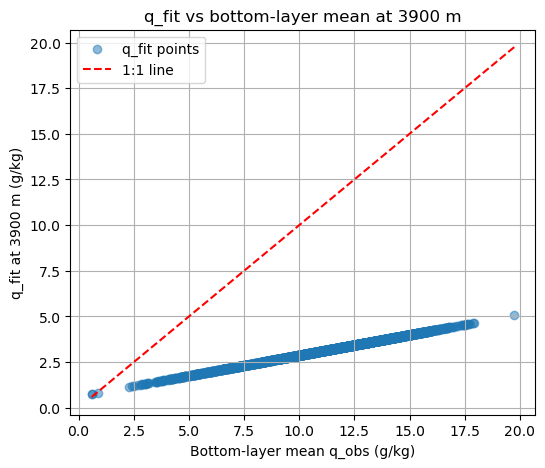

In [81]:
# --- PARAMETERS ---

test_level_alt = 3900  # m

bottom_1km_idx = 51    # indices corresponding to bottom 1 km (as in your q_fit regression)

# --- find closest index to 2000 m ---

# assuming interp_alt is the same for all rows

alt_ref = np.array(df['interp_alt'].iloc[0])

lev_idx = np.argmin(np.abs(alt_ref - test_level_alt))

print(f"Testing level {test_level_alt} m at index {lev_idx}")

# --- extract q_obs at this level for all times ---
q_obs_level = df['q_obs'].apply(lambda x: np.array(x)[lev_idx])

# --- compute bottom-layer mean q_obs for all times ---
q_bottom_layer = df['q_obs'].apply(lambda x: np.mean(x[:bottom_1km_idx]))

# --- extract q_fit at this level ---
q_fit_level = df['q_fit'].apply(lambda x: np.array(x)[lev_idx])

# --- correlation and RMSE ---

corr, pval = pearsonr(q_fit_level, q_obs_level)

rmse = np.sqrt(np.mean((q_fit_level - q_obs_level)**2))

print(f"Level {test_level_alt} m: correlation = {corr:.2f}, RMSE = {rmse:.2f} g/kg")

# --- scatter plot of q_fit vs bottom-layer mean ---
plt.figure(figsize=(6,5))

plt.scatter(q_bottom_layer, q_fit_level, alpha=0.5, label='q_fit points')

plt.plot([q_bottom_layer.min(), q_bottom_layer.max()],
         [q_bottom_layer.min(), q_bottom_layer.max()],
         color='red', linestyle='--', label='1:1 line')
plt.xlabel('Bottom-layer mean q_obs (g/kg)')

plt.ylabel(f'q_fit at {test_level_alt} m (g/kg)')

plt.title(f'q_fit vs bottom-layer mean at {test_level_alt} m')

plt.legend()

plt.grid()

plt.show()

# # --- optional: plot a few full profiles ---
# for idx in [0, 1200, 1500]:
#     qfit = np.array(df['q_fit'].iloc[idx])
#     qobs = np.array(df['q_obs'].iloc[idx])
#     alt  = np.array(df['interp_alt'].iloc[idx])
    
#     plt.figure(figsize=(5,6))
#     plt.plot(qfit, alt, label='q_fit', linewidth=2)
#     plt.plot(qobs, alt, label='q_obs', linewidth=1)
#     plt.xlabel('Specific humidity (g/kg)')
#     plt.ylabel('Altitude (m)')
#     plt.title(f'Example day index {idx}')
#     plt.legend()
#     plt.grid()
#     plt.show()


In [38]:
blt_virt_custom_boundaries = [df['blt_virt'].min(), df['blt_virt'].quantile(1/3), df['blt_virt'].quantile(2/3), df['blt_virt'].max()]

df['blt_virt_tercile'] = pd.cut(df['blt_virt'], bins=blt_virt_custom_boundaries, labels=[1, 2, 3], include_lowest=True)

#The blt_g values for the three terciles range from:

#-55.8 to -8.8 J/kg 
#-8.8 to 10.20J/kg 
#10.0 to 72.8 J/kg

blt_virt_custom_boundaries

[-27.035078384853904,
 -3.200940279161744,
 1.9571934910467077,
 22.985779815338276]

In [96]:
# idx = 52 

# tev_qfit = df['tev_qfit'].iloc[idx]

# temp = df['interp_temp'].iloc[idx]

# tpv_qobs = df['tpv_qobs'].iloc[idx]

# tpv_qfit = df['tpv_qfit'].iloc[idx]

# tev_qobs = df['tev_qobs'].iloc[idx]

# alt = df['interp_alt'].iloc[idx]

# q = df['q_obs'].iloc[idx] / 1000

# qfit = df['q_fit'].iloc[idx] / 1000

# test_tev_qobs = temp * (1 + 0.61*q)

# test_tev_qfit = temp * (1 + 0.61*qfit)

# print(df['blt_virt'].iloc[idx])

# plt.plot(tev_qfit, alt, label='Tev qfit', color='blue')

# plt.plot(tpv_qfit, alt, label='Tpv qfit', color='blue', linestyle='--')

# plt.plot(tev_qobs, alt, label='Tev q', color='orange')

# plt.plot(tpv_qobs, alt, label='Tpv q', color='orange', linestyle='--')

# plt.legend()

# plt.title("Virtual temperature of environment vs. parcel using qfit vs. q")

# plt.grid()

# plt.show()

# plt.plot(q, alt, label='q', color='orange')

# plt.plot(qfit, alt, label='qfit', color='blue')

# plt.grid()

# plt.legend()

# plt.title("q vs. qfit profile")

# plt.show()

# plt.plot(temp, alt, label='temp')

# plt.plot(test_tev_qobs, alt, label='virtual temp using q')

# plt.plot(test_tev_qfit, alt, label='virtual temp using qfit')

# plt.title("Self-calculated virtual temperature")

# plt.grid()

# plt.show()

# plt.plot(test_tev_qfit-test_tev_qobs, alt, label='diff in tv using q vs. qfit')

# plt.title("Difference in self-calculated Tv using q vs. qfit")

# plt.grid()

# plt.xlim(-1, 1)

# plt.show()

In [21]:
# converts empty strings to nans 

df['blt_bug'] = pd.to_numeric(df['blt_bug'], errors='coerce')

df['blc_bug'] = pd.to_numeric(df['blc_bug'], errors='coerce')

df['br_bug'] = pd.to_numeric(df['br_bug'], errors='coerce')

In [23]:
print(df.shape)

valid = df['blt_bug'].dropna()

print(valid.shape)

(2437, 15)
(2435,)


In [26]:
blt_bug_custom_boundaries = [df['blt_bug'].min(), df['blt_bug'].quantile(1/3), df['blt_bug'].quantile(2/3), df['blt_bug'].max()]

df['blt_bug_tercile'] = pd.cut(df['blt_bug'], bins=blt_bug_custom_boundaries, labels=[1, 2, 3], include_lowest=True)

blt_bug_custom_boundaries

### before without dewpoint update: [-15.392552355461788, -1.6714778557652994, 1.1475111582721136, 12.75832838366125]

[-58.40665398157722, -7.888215609852022, 9.478289440843382, 69.57501387514344]

In [27]:
# blt_virt_custom_boundaries = [df['blt_virt'].min(), df['blt_virt'].quantile(1/3), df['blt_virt'].quantile(2/3), df['blt_virt'].max()]

# df['blt_virt_tercile'] = pd.cut(df['blt_virt'], bins=blt_virt_custom_boundaries, labels=[1, 2, 3], include_lowest=True)

# blt_virt_custom_boundaries

# ### before without dewpoint update: [-15.392552355461788, -1.6714778557652994, 1.1475111582721136, 12.75832838366125]

In [28]:
# blc_virt_custom_boundaries = [df['blc_virt'].min(), df['blc_virt'].quantile(1/3), df['blc_virt'].quantile(2/3), df['blc_virt'].max()]

# df['blc_virt_tercile'] = pd.cut(df['blc_virt'], bins=blc_virt_custom_boundaries, labels=[1, 2, 3], include_lowest=True)

# blc_virt_custom_boundaries

# ### before without dewpoint update: [-15.392552355461788, -1.6714778557652994, 1.1475111582721136, 12.75832838366125]

/tmp/ipykernel_12071/3267297109.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([str(int(tick)) for tick in ax.get_yticks()])
/tmp/ipykernel_12071/3267297109.py:51: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(int(tick)) for tick in ax.get_xticks()])


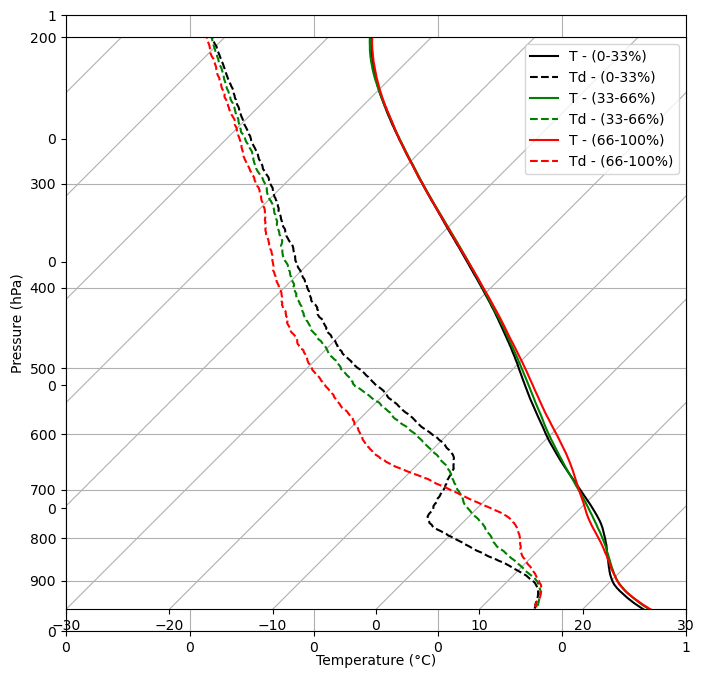

In [39]:
fig, ax = plt.subplots(figsize=(8, 8))

skew = SkewT(fig, rotation=45)

terc_pres = df['interp_pres'][0]

terc_pres = terc_pres[terc_pres <= 1000]

terc_temps = df.groupby('blt_virt_tercile')['interp_temp'].mean().values * units.degC

terc_dps = df.groupby('blt_virt_tercile')['interp_dp'].mean().values * units.degC

colors = ['black', 'green', 'red']

for tercile in range(0, 3):
    
    lower_bound = tercile * 33
    
    upper_bound = (tercile + 1) * 33 if tercile < 2 else 100
    
    label_temp = f'T - ({lower_bound}-{upper_bound}%)'
    
    label_dp = f'Td - ({lower_bound}-{upper_bound}%)'
        
    skew.plot(terc_pres, terc_temps[tercile], label=label_temp, color=colors[tercile])
    
    skew.plot(terc_pres, terc_dps[tercile], label=label_dp, linestyle='--', color=colors[tercile])

ax.grid(True)

plt.ylim(975, 200)

plt.xlim(-30, 30)

plt.legend()

# Adding y-label and x-label

plt.ylabel('Pressure (hPa)')

# Adjust the position of the x-axis label

plt.xlabel('Temperature (°C)', labelpad=15)

# Remove duplicate y-axis labels

ax.set_yticklabels([str(int(tick)) for tick in ax.get_yticks()])

# Remove duplicate x-axis labels

ax.set_xticklabels([str(int(tick)) for tick in ax.get_xticks()])

plt.show()


In [30]:
# x = df_corr['blt_virt'].values

# y = df_corr['blc_virt'].values

# r, p = pearsonr(x, y)

# print(r, p)

In [31]:
# r, p = pearsonr(df['blc_virt'], df['blt_virt'])

# print(r, p)

In [32]:
# corr = df['blt'].corr(df['Blc'])

# print(corr)

In [33]:
# r, p = pearsonr(df['Blc'], df['Br'])

# print(r, p)

In [41]:
with open('/home/annierosen16/soundings_fig1&4_final.pkl', 'wb') as file:
    
    pickle.dump(df, file)

It is noteworthy that the
temperature and dew point are similar among these three terciles of BLT near the surface (below 900hPa) but clearly
different from above 900 hPa up to at least 400 hPa AGL, which indicates the importance of LT humidity.

For the lower tercile (0% - 33%) of BLT (Figure 4a), dew point values are substantially lower than those for the middle and upper tercile of the BLT (Figures 4b and 4c). The sharp decrease of dew point values with height, near-constant temperature, and large gap between the temperature and dew point profiles at 700-900 hPa suggest strong dry shallow
convection. 

For the middle tercile (Figure 4b), dewpoint and temperature decrease gradually with a height between
900 hPa and 700 hPa, and the gap between the dew point and temperature profiles is smaller than those for the lower
tercile of the BLT (Figure 4a). These features suggest a mixture of dry and moist shallow convection. 

For the upper tercile of BLT (Figure 4c, 67% – 100%), dew point values are nearly constant from the surface to 700 hPa, and the humidity of free troposphere, as indicated by the gap between temperature and dew point profiles, is substantially wetter (implying higher RH) than for the middle and lower tercile of the BLT. These features suggest that moist shallow convection dominates LT. 

Higher dew point values between 700 hPa and 500 hPa also suggest a more humid middle troposphere associated with the upper BLT tercile (Figure 4c) than with the middle and lower BLT tercile (Figure 4a and 4b). Thus, Figure 4 suggests that BLT variations are strongly influenced by the humidity in the lower and middle
troposphere. 